In [29]:
# CELL 1: Load data
import pandas as pd
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
DATA_DIR = Path(r".\dataset")
NAMA_FILE = "Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta - tabel.xls"
file_path = DATA_DIR / NAMA_FILE

print('=== TAHAP 1: MEMBACA DATA ===')
try:
    df = pd.read_html(file_path)[0]
    df.columns = df.columns.str.lower().str.strip()
    print(f'[INFO] File dimuat: {NAMA_FILE} ({df.shape[0]} baris, {df.shape[1]} kolom)')
    missing = df.isnull().sum()[df.isnull().sum() > 0]
    if not missing.empty:
        print('[INFO] Kolom dengan NaN:', missing.to_dict())
    if 'categori' in df.columns:
        print(df['categori'].value_counts(dropna=False))
    elif 'kategori' in df.columns:
        print(df['kategori'].value_counts(dropna=False))
except Exception as e:
    print(f'[ERROR] Gagal membaca file: {e}')
    print("Periksa nama file dan folder 'dataset'.")

=== TAHAP 1: MEMBACA DATA ===
[INFO] File dimuat: Data_Indeks Standar Pencemar Udara (ISPU) di Provinsi DKI Jakarta - tabel.xls (3501 baris, 13 kolom)
[INFO] Kolom dengan NaN: {'pm_sepuluh': 264, 'pm_duakomalima': 61, 'sulfur_dioksida': 56, 'karbon_monoksida': 50, 'ozon': 46, 'nitrogen_dioksida': 69, 'max': 8, 'parameter_pencemar_kritis': 65, 'kategori': 1}
kategori
SEDANG                2694
BAIK                   444
TIDAK SEHAT            341
TIDAK ADA DATA          20
SANGAT TIDAK SEHAT       1
NaN                      1
Name: count, dtype: int64


In [30]:
# CELL 2: Cleaning & encoding (anti-leakage)
print('=== TAHAP 2: PREP DATA ===')
df_prep = df.copy()
kolom_mapping = {'pm_sepuluh': 'pm10', 'pm_duakomalima': 'pm25', 'sulfur_dioksida': 'so2', 'karbon_monoksida': 'co', 'ozon': 'o3', 'nitrogen_dioksida': 'no2'}
df_prep = df_prep.rename(columns=kolom_mapping)
kolom_buang = ['periode_data', 'bulan', 'tanggal', 'max', 'parameter_pencemar_kritis']
df_prep = df_prep.drop(columns=[col for col in kolom_buang if col in df_prep.columns])
df_prep = df_prep.dropna(subset=['kategori'])
df_prep = df_prep[df_prep['kategori'] != 'TIDAK ADA DATA']
df_prep['kategori'] = df_prep['kategori'].replace('SANGAT TIDAK SEHAT', 'TIDAK SEHAT')
if 'stasiun' in df_prep.columns:
    def rapikan_stasiun(nama):
        nama = str(nama).upper()
        if 'DKI1' in nama: return 'DKI1'
        if 'DKI2' in nama: return 'DKI2'
        if 'DKI3' in nama: return 'DKI3'
        if 'DKI4' in nama: return 'DKI4'
        if 'DKI5' in nama: return 'DKI5'
        return nama
    df_prep['stasiun'] = df_prep['stasiun'].apply(rapikan_stasiun)
kolom_polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
for col in kolom_polutan:
    if col in df_prep.columns:
        df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')
map_kategori = {'BAIK': 0, 'SEDANG': 1, 'TIDAK SEHAT': 2}
df_prep['kategori_label'] = df_prep['kategori'].map(map_kategori)
if 'stasiun' in df_prep.columns:
    df_prep = pd.get_dummies(df_prep, columns=['stasiun'], drop_first=True)
for col in df_prep.select_dtypes(include=['bool']).columns:
    df_prep[col] = df_prep[col].astype(int)
X_raw = df_prep.drop(columns=['kategori', 'kategori_label'])
y = df_prep['kategori_label']
print('[INFO] Data siap di-split. NaN dipertahankan untuk imputasi yang aman.')

=== TAHAP 2: PREP DATA ===
[INFO] Data siap di-split. NaN dipertahankan untuk imputasi yang aman.


In [31]:
# CELL 2: Temporal split, imputation & training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
print('=== TAHAP 4: TEMPORAL SPLIT & TRAINING ===')
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, shuffle=False)
print(f'[INFO] Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
kolom_polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
median_train = X_train[kolom_polutan].median()
X_train[kolom_polutan] = X_train[kolom_polutan].fillna(median_train)
X_test[kolom_polutan] = X_test[kolom_polutan].fillna(median_train)
X_train = X_train.copy(); X_test = X_test.copy()
print('[INFO] Memulai pelatihan model...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print('[INFO] Pelatihan selesai.')
y_pred = rf_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f'[RESULT] Akurasi (temporal): {akurasi * 100:.2f}%')
target_names = ['BAIK', 'SEDANG', 'TIDAK SEHAT']
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=target_names))

=== TAHAP 4: TEMPORAL SPLIT & TRAINING ===
[INFO] Train: 2784 | Test: 696
[INFO] Memulai pelatihan model...
[INFO] Pelatihan selesai.
[RESULT] Akurasi (temporal): 99.43%

--- Classification Report ---
              precision    recall  f1-score   support

        BAIK       1.00      0.95      0.98        65
      SEDANG       0.99      1.00      1.00       563
 TIDAK SEHAT       1.00      0.99      0.99        68

    accuracy                           0.99       696
   macro avg       1.00      0.98      0.99       696
weighted avg       0.99      0.99      0.99       696



=== TAHAP 5: VISUALISASI EVALUASI ===


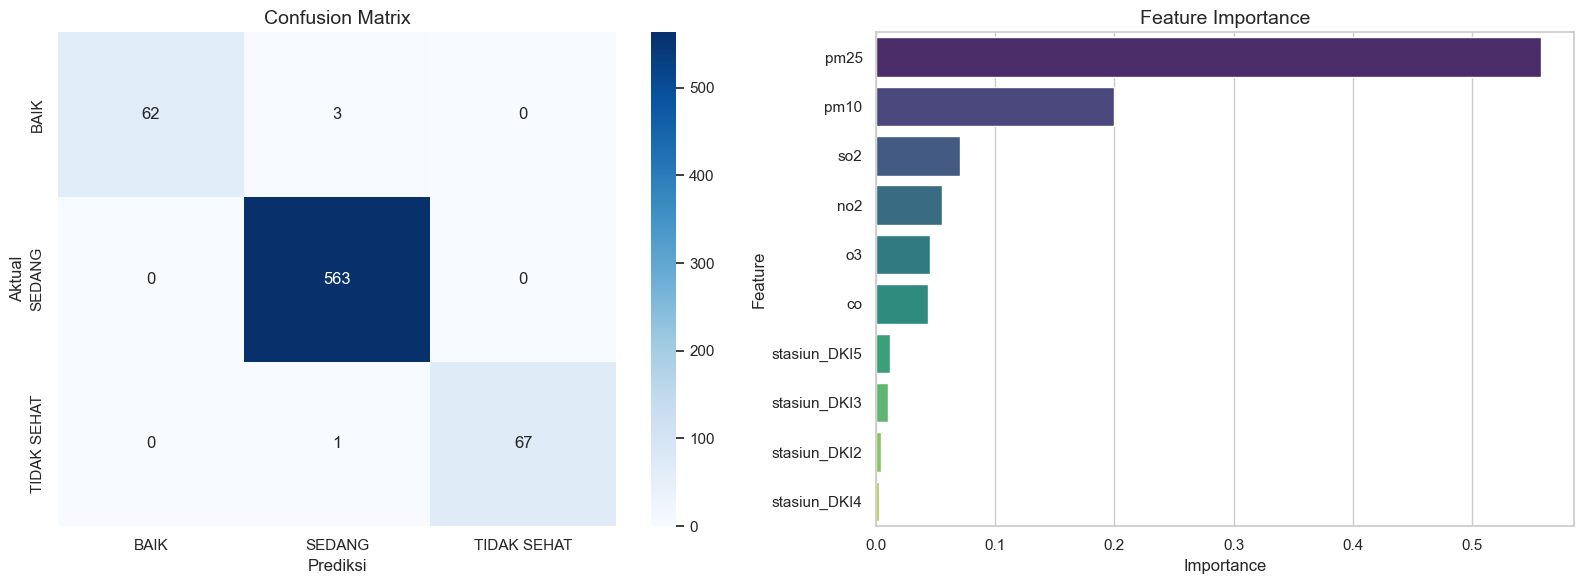

[INFO] Evaluasi disimpan: evaluasi_model_ispu.png


In [32]:
# CELL 3: Visual evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
print('=== TAHAP 5: VISUALISASI EVALUASI ===')
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')
importances = rf_model.feature_importances_
fitur = X_train.columns
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=fitur[indices], ax=axes[1], palette='viridis')
axes[1].set_title('Feature Importance', fontsize=14)
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')
plt.tight_layout()
nama_file_eval = 'evaluasi_model_ispu.png'
plt.savefig(nama_file_eval, dpi=300, bbox_inches='tight')
plt.show()
print(f'[INFO] Evaluasi disimpan: {nama_file_eval}')

In [37]:
# CELL 4: Time series cross-validation (5 folds)
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
print('TIME SERIES CROSS-VALIDATION')
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
fold = 1
kolom_polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
for train_index, test_index in tscv.split(X_raw):
    X_train_cv = X_raw.iloc[train_index].copy()
    X_test_cv = X_raw.iloc[test_index].copy()
    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]
    median_train_cv = X_train_cv[kolom_polutan].median()
    X_train_cv[kolom_polutan] = X_train_cv[kolom_polutan].fillna(median_train_cv)
    X_test_cv[kolom_polutan] = X_test_cv[kolom_polutan].fillna(median_train_cv)
    model_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = model_cv.predict(X_test_cv)
    akurasi_fold = accuracy_score(y_test_cv, y_pred_cv)
    cv_scores.append(akurasi_fold)
    print(f'Fold {fold} | Train: {len(X_train_cv)} | Test: {len(X_test_cv)} | Acc: {akurasi_fold*100:.2f}%')
    fold += 1
rata_rata_akurasi = np.mean(cv_scores) * 100
std_akurasi = np.std(cv_scores) * 100
print(f'Rata-rata akurasi: {rata_rata_akurasi:.2f}% | StdDev: {std_akurasi:.2f}%')


TIME SERIES CROSS-VALIDATION
Fold 1 | Train: 580 | Test: 580 | Acc: 97.76%
Fold 2 | Train: 1160 | Test: 580 | Acc: 94.14%
Fold 3 | Train: 1740 | Test: 580 | Acc: 90.17%
Fold 4 | Train: 2320 | Test: 580 | Acc: 97.93%
Fold 5 | Train: 2900 | Test: 580 | Acc: 99.48%
Rata-rata akurasi: 95.90% | StdDev: 3.36%


In [34]:
# CELL 5: Forensic fold summary
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
print('=== TAHAP 7: INVESTIGASI FOLD ===')
df_sync = df.loc[X_raw.index].copy()
tscv = TimeSeriesSplit(n_splits=5)
fold = 1
ringkasan_folds = []
for train_index, test_index in tscv.split(X_raw):
    df_test_fold = df_sync.iloc[test_index]
    tanggal_mulai = df_test_fold['tanggal'].iloc[0] if 'tanggal' in df_test_fold.columns else 'N/A'
    tanggal_akhir = df_test_fold['tanggal'].iloc[-1] if 'tanggal' in df_test_fold.columns else 'N/A'
    pm25_mean = pd.to_numeric(df_test_fold.get('pm_duakomalima'), errors='coerce').mean()
    pm10_mean = pd.to_numeric(df_test_fold.get('pm_sepuluh'), errors='coerce').mean()
    total_data = len(df_test_fold)
    tidak_sehat = len(df_test_fold[df_test_fold['kategori'].astype(str).str.contains('TIDAK SEHAT', na=False)])
    persentase_buruk = (tidak_sehat / total_data) * 100 if total_data > 0 else None
    ringkasan_folds.append({'Fold': f'Fold {fold}', 'Tgl Mulai': tanggal_mulai, 'Tgl Akhir': tanggal_akhir, 'Rata2 PM2.5': round(pm25_mean, 2) if pd.notna(pm25_mean) else None, 'Rata2 PM10': round(pm10_mean, 2) if pd.notna(pm10_mean) else None, '% Udara Buruk': f"{round(persentase_buruk,2)}%" if persentase_buruk is not None else None})
    fold += 1
df_bukti = pd.DataFrame(ringkasan_folds)
display(df_bukti)

=== TAHAP 7: INVESTIGASI FOLD ===


,Fold,Tgl Mulai,Tgl Akhir,Rata2 PM2.5,Rata2 PM10,% Udara Buruk
0,Fold 1,15,18,82.23,58.33,14.83%
1,Fold 2,19,22,75.64,53.39,11.72%
2,Fold 3,23,29,50.91,38.73,0.52%
3,Fold 4,30,14,81.57,49.97,18.97%
4,Fold 5,15,30,73.74,46.16,8.79%


In [35]:
# CELL 6: Inspect Fold 3 (actual dates)
print('=== TAHAP 8: INSPEKSI FOLD 3 ===')
splits = list(tscv.split(X_raw))
train_idx_3, test_idx_3 = splits[2]
df_fold3_test = df.loc[X_raw.index[test_idx_3]].copy()
if 'periode_data' in df_fold3_test.columns:
    print(df_fold3_test['periode_data'].value_counts(dropna=False))
else:
    print('Kolom periode_data tidak ditemukan.')
if 'bulan' in df_fold3_test.columns:
    print(df_fold3_test['bulan'].value_counts(dropna=False))
else:
    print('Kolom bulan tidak ditemukan.')
df_fold3_test['pm_duakomalima'] = pd.to_numeric(df_fold3_test.get('pm_duakomalima'), errors='coerce')
summary_bulan = df_fold3_test.groupby('bulan')['pm_duakomalima'].agg(['mean', 'count']).rename(columns={'mean': 'Rata-rata PM2.5', 'count': 'Jumlah Hari (Data)'})
display(summary_bulan)

=== TAHAP 8: INSPEKSI FOLD 3 ===
periode_data
202501    147
202502    137
202412    109
202504    101
202503     74
202505     12
Name: count, dtype: int64
bulan
1     147
2     137
12    109
4     101
3      74
5      12
Name: count, dtype: int64


,Rata-rata PM2.5,Jumlah Hari (Data)
bulan,,
1,44.945578,147
2,54.798507,134
3,50.082192,73
4,64.896907,97
5,75.500000,12
12,39.568807,109


=== TAHAP 8: SIMULASI PREDIKSI DATA BARU ===


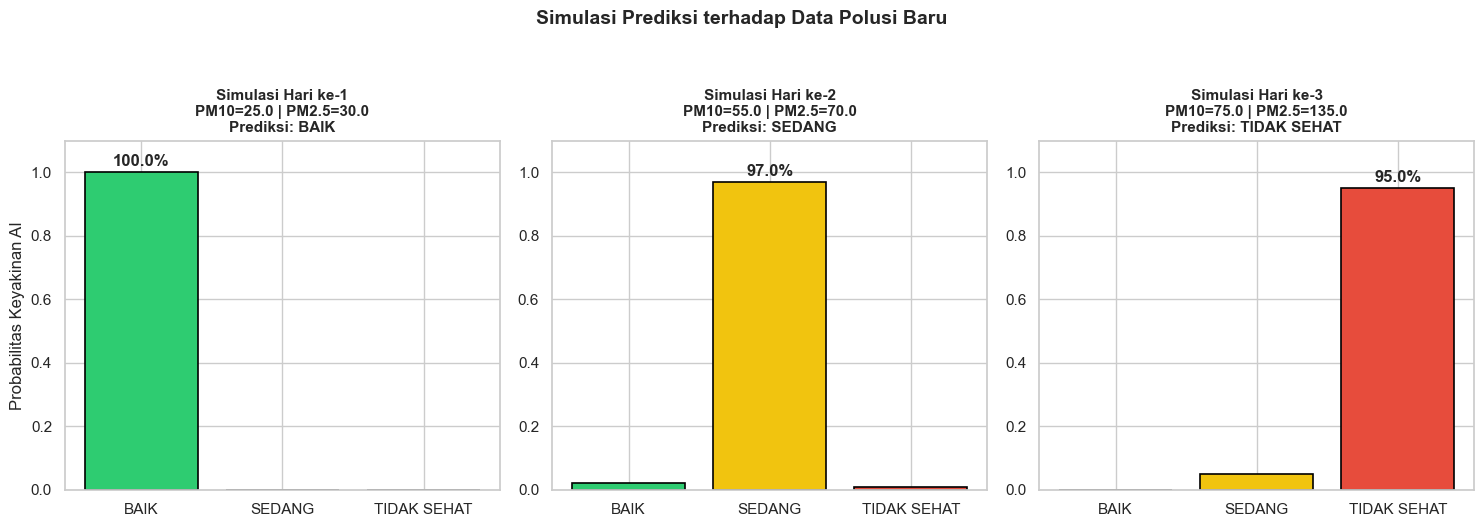

Grafik simulasi disimpan sebagai 'simulasi_prediksi_ispu.png'


In [41]:
# ==========================================
# CELL 9: SIMULASI PREDIKSI DATA BARU & PROBABILITAS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

print("=== TAHAP 8: SIMULASI PREDIKSI DATA BARU ===")

# Mapping kebalikan untuk narik nama label
map_kategori_terbalik = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT'}

# Data simulasi: [pm10, pm25, so2, co, o3, no2]
data_baru = [
    [25.0,  30.0, 12.0,  6.0,  15.0,  8.0],   # Max 30 -> BAIK
    [55.0,  70.0, 25.0, 10.0,  55.0, 15.0],   # Max 70 -> SEDANG
    [75.0, 135.0, 30.0, 15.0, 100.0, 20.0],   # Max 135 (PM2.5) -> TIDAK SEHAT
]

kolom_polutan = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
df_simulasi = pd.DataFrame(data_baru, columns=kolom_polutan)

# Tambahkan kolom one-hot stasiun agar bentuknya sama persis dengan X_train
for col in ['stasiun_DKI2', 'stasiun_DKI3', 'stasiun_DKI4', 'stasiun_DKI5']:
    df_simulasi[col] = 0 # Kita asumsikan simulasi ini dari DKI1 (semua 0)

# Pastikan urutan kolom sama persis dengan data latih
df_simulasi = df_simulasi[X_train.columns]

# Prediksi Kategori & Probabilitas
prediksi = rf_model.predict(df_simulasi)
y_proba = rf_model.predict_proba(df_simulasi)

# VISUALISASI PROBABILITAS PREDIKSI
nama_kelas = ['BAIK', 'SEDANG', 'TIDAK SEHAT']
warna_kelas = ['#2ecc71', '#f1c40f', '#e74c3c']

fig, axes = plt.subplots(1, len(data_baru), figsize=(15, 5))

for i, (proba, pred) in enumerate(zip(y_proba, prediksi)):
    axes[i].bar(nama_kelas, proba, color=warna_kelas, edgecolor='black', linewidth=1.2)
    axes[i].set_title(
        f'Simulasi Hari ke-{i+1}\n'
        f'PM10={data_baru[i][0]} | PM2.5={data_baru[i][1]}\n'
        f'Prediksi: {map_kategori_terbalik[pred]}',
        fontsize=11, fontweight='bold'
    )
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Probabilitas Keyakinan AI' if i == 0 else '')
    
    # Tambah angka probabilitas di atas bar
    for j, p in enumerate(proba):
        if p > 0.05:
            axes[i].text(j, p + 0.02, f'{p*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Simulasi Prediksi terhadap Data Polusi Baru', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
nama_plot = 'simulasi_prediksi_ispu.png'
plt.savefig(nama_plot, dpi=300, bbox_inches='tight')
plt.show()
print(f"Grafik simulasi disimpan sebagai '{nama_plot}'")